# Les matrices
*Source : Deeplearning AI + Claude ai*


## Sommaire
- [ 1 - Représentation d'un système d'équations linéaires à l'aide de matrice](#1)
  - [ 1.1 - System d'équations linéaires](#1.1)
  - [ 1.2 - Système d'équation linéaire sous forme de matrice](#1.2)
  - [ 1.3 - Calcul du déterminant d'une matrice](#1.3)
- [ 2 - Visualisation des systèmes 2x2 sous forme de lignes de tracé](#2)
  - [ 2.1 - La représentation du système sous forme de matrice](#2.1)
  - [ 2.2 - La représentation graphique de la solution](#2.2)
  - [ 2.3 - Système d'équations linéaires singulière](#2.3)
- [ 3 - Elimination gaussienne](#3)
  - [ 3.1 - Fonctions auxiliaires](#3.1)
  - [ 3.2 - Forme échelonnées réduite](#3.2)
  - [ 3.3 - Substitution arrière](#3.3)
  - [ 3.4 - Elimination de Gauss](#3.4)
- [ 4 - Multiplication matricielle](#4)
  - [ 4.1 - Multiplication de matrice avec Python](#4.1)
  - [ 4.2 - Convention matracielle et Broadcasting](#4.2)
- [ 5 - Transformations linéaires](#5)
  - [ 5.1 - Transformations](#5.1)
  - [ 5.2 - Transformation linéaires](#5.2)
  - [ 5.3 - Transformations définies comme une multiplication matricielle](#5.3)
  - [ 5.4 - Transformation standard dans un plan](#5.4)
  - [ 5.5 - Application : infographie et traitement d'image](#5.5)


  




In [75]:
import os
if os.path.exists('preparation_formation'):
    !git -C preparation_formation pull
else:
    !git clone https://github.com/cecile-learns/preparation_formation.git

Already up to date.


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

<a name='1'></a>

## 1 - Représentation d'un système d'équations linéaires à l'aide de matrices

<a name='1.1'></a>

### 1.1 - Système d'équations linéaires

Un **système d'équations linéaires** est un ensemble d'une ou plusieurs équations linéaires impliquant les mêmes variables. Par exemple :

$$
\begin{cases}
-x_1+3x_2=7, \\ 3x_1+2x_2=1, \end{cases}\
$$

est un système de deux équations à deux inconnues $x_1$ et $x_2$.

**Résoudre** un système d'équations linéaires signifie trouver les valeurs des variables $x_1$ et $x_2$ telles que toutes les équations soient simultanément satisfaites.

Un système linéaire est **non singulier** s'il admet une solution unique ; sinon, il est dit **singulier**, il peut admettre aucune solution ou une inifinité de solution.

<a name='1.2'></a>

### 1.2 - Systèmes d'équations linéaires sous forme de matrices

Les systèmes d'équations linéaire peuvent être représentées sous  forme de matrices comme ci-dessous :

$$
\begin{bmatrix}
-1 & 3 & 7 \\
3 & 2 & 1
\end{bmatrix}
$$

Chaque ligne représente une équation du système. La première colonne représente les coefficients de $x_1$ dans le système, la deuxième colonne représente les coefficients de $x_2$, et la troisième colonne représente les valeurs constantes à droite du signe égal dans les équations.

On peut également représenter les coefficients du système $(1)$ par une matrice $A$ dédiée, comme suit :

$$
\begin{bmatrix}
-1 & 3\\
3 & 2
\end{bmatrix}
$$

et les sorties du système par un vecteur $b$, comme ceci :

$$
\begin{bmatrix}
7 \\
1
\end{bmatrix}
$$

La matrice $A$ et le vecteur $b$ sont représentés ci-dessous dans `NumPy` :

In [7]:
A=np.array([[-1,3],[3,2]],dtype=np.dtype(float))
b=np.array([7,1],dtype=np.dtype(float))

print(f"Matrice A: \n{A}")
print(f"Vecteur b: \n{b}")

Matrice A: 
[[-1.  3.]
 [ 3.  2.]]
Vecteur b: 
[7. 1.]


In [8]:
#Dimension de la matrice A et du vecteur b
print(f"Dimension de la matrice A : {np.shape(A)}")
print(f"Dimension du vecteur b : {np.shape(b)}")

Dimension de la matrice A : (2, 2)
Dimension du vecteur b : (2,)


In [9]:
#Résolution du système d'équations linéaires
x=np.linalg.solve(A,b)
print(f"Solution : {x}")

#autres présentation possible
print(f"Solution : x1={x[0]:.0f} et x2={x[1]:.0f}")

Solution : [-1.  2.]
Solution : x1=-1 et x2=2


<a name='1.3'></a>

### 1.3 - Calcul du déterminant d'une matrice

Pour une matrice carrée (n×n), on peut calculer le déterminant,
un scalaire qui indique si la matrice est inversible.

- det(A) ≠ 0 → matrice non singulière → solution unique
- det(A) = 0 → matrice singulière → soit aucune solution,
  soit infinité de solutions (équations redondantes ou contradictoires)

**Déterminant 2×2 :**

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}
\Rightarrow det(A) = ad - bc$$

**Déterminant 3×3 (règle de Sarrus) :**

$$det(A) = a(ei-fh) - b(di-fg) + c(dh-eg)$$

où les lettres correspondent aux éléments ligne par ligne.




In [10]:
d=np.linalg.det(A)
print(f"Déterminant de la matrice A : {d:.2f}")

Déterminant de la matrice A : -11.00


**Matrice non carrées - Notion de rang :**

Pour une matrice non carrée (m×n), le déterminant n'existe pas.
On utilise le **rang** : le nombre de lignes (ou colonnes)
linéairement indépendantes et si rang=n alors il y a une unique solution..
(voir partie éliminiation gaussienne)

In [11]:
B = np.array([[1, 2, 3], [4, 5, 6]], dtype=float)
print(f"Rang de B : {np.linalg.matrix_rank(B)}")

Rang de B : 2


<a name='2'></a>

## 2 - Visualisation des systèmes 2x2 sous forme de lignes de tracé



<a name='2.1'></a>

### 2.1 - Représentation du système sous forme de matrice

Pour avoir matrice A comme suit :

$$
\begin{bmatrix}
-1 & 3 & 7 \\
3 & 2 & 1
\end{bmatrix}
$$

2 solutions :
- Créer une nouvelle matrice avec ces valeurs,
- Empiler horizontalement les matrices $A$ et $b$ créées précédemment avec la fonction `np.hstack()`
Attention : elle nécessite de redimensionner le vecteur $b$ avant l'empilement, car sa forme actuelle est $(2,)$.

Le code ci-dessous inclut la commande `.reshape((2, 1))` pour permettre l'empilement horizontal.

In [12]:
A_system = np.hstack((A, b.reshape((2, 1))))

print(A_system)

[[-1.  3.  7.]
 [ 3.  2.  1.]]


In [13]:
#Pour extraire une ligne de la matrice
print( A_system[0])

[-1.  3.  7.]


<a name='2.2'></a>

### 2.2 - Représentation graphique de la solution

Une équation linéaire à deux inconnues (ici, $x_1$ et $x_2$) peut être représentée géométriquement par une droite dans le plan. On appelle cela le **graphique de l'équation linéaire**. Dans le cas d'un système de deux équations, chaque équation est représentée par deux droites, et la solution correspond à leur point d'intersection.



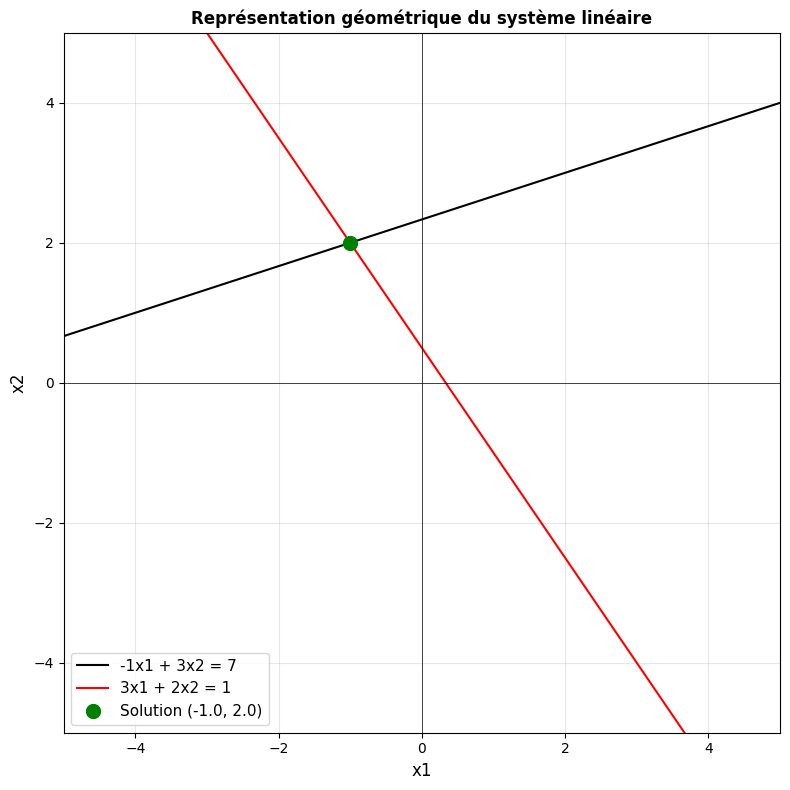

In [14]:
#Code Claude Ai
def plot_lines(A_system):
    fig, ax = plt.subplots(figsize=(8, 8))

    x = np.linspace(-5, 5, 200)

    # Droite 1 : -x1 + 3x2 = b1  →  x2 = (b1 + x1) / 3
    a1, b1, c1 = A_system[0, 0], A_system[0, 1], A_system[0, 2]
    y1 = (c1 - a1 * x) / b1
    ax.plot(x, y1, color="black", label=f"{a1:.0f}x1 + {b1:.0f}x2 = {c1:.0f}")

    # Droite 2 : 3x1 + 2x2 = b2  →  x2 = (b2 - 3x1) / 2
    a2, b2, c2 = A_system[1, 0], A_system[1, 1], A_system[1, 2]
    y2 = (c2 - a2 * x) / b2
    ax.plot(x, y2, color="red", label=f"{a2:.0f}x1 + {b2:.0f}x2 = {c2:.0f}")

    # Gestion des cas singuliers et non singuliers
    try:
        solution = np.linalg.solve(A_system[:, :2], A_system[:, 2])
        ax.plot(solution[0], solution[1], 'go', markersize=10,
                label=f"Solution ({solution[0]:.1f}, {solution[1]:.1f})")
    except np.linalg.LinAlgError:
        det = np.linalg.det(A_system[:, :2])
        if det == 0:
            rang = np.linalg.matrix_rank(A_system[:, :2])
            rang_aug = np.linalg.matrix_rank(A_system)
            if rang == rang_aug:
                msg = "Infinité de solutions (droites confondues)"
            else:
                msg = "Aucune solution (droites parallèles)"
        ax.text(0, 0, msg, fontsize=12, color="purple", ha='center',
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    ax.set_xlabel("x1", fontsize=12)
    ax.set_ylabel("x2", fontsize=12)
    ax.set_title("Représentation géométrique du système linéaire", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_lines(A_system)

<a name='2.3'></a>

## 2.3 - Système d'équations linéaires singulier

### Contradictoire = sans solution
Soit un autre système d'équations linéaires :

$$
\begin{cases}
-x_1+3x_2=7, \\ 3x_1-9x_2=1, \end{cases}\
$$

Calculons le déterminant de la matrice correspondante.

In [15]:
A_2 = np.array([
        [-1, 3],
        [3, -9]
    ], dtype=np.dtype(float))

b_2 = np.array([7, 1], dtype=np.dtype(float))

d_2 = np.linalg.det(A_2)

print(f"Determinant of matrix A_2: {d_2:.0f}")

Determinant of matrix A_2: 0


In [16]:
try:
    x_2 = np.linalg.solve(A_2, b_2)
except np.linalg.LinAlgError as err:
    print(err)

Singular matrix


In [17]:
A_2_system = np.hstack((A_2, b_2.reshape((2, 1))))
print(A_2_system)

[[-1.  3.  7.]
 [ 3. -9.  1.]]


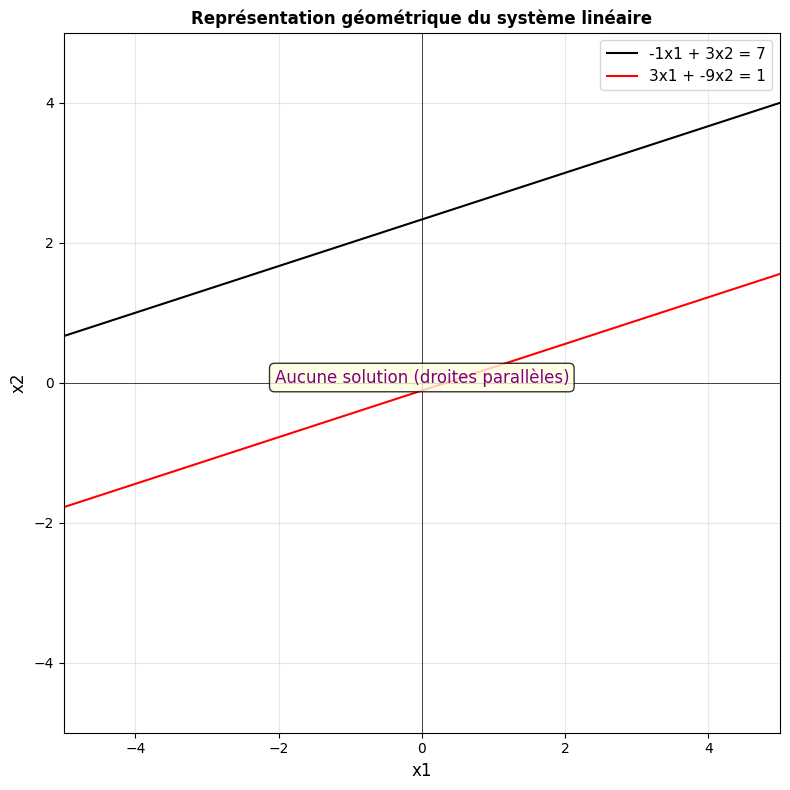

In [18]:
plot_lines(A_2_system)

### Redondant = infinité de solutions
Soit un autre système d'équations linéaires :
$$
\begin{cases}
-x_1+3x_2=7, \\ 3x_1-9x_2=-21,
\end{cases}\
$$

Calculons le déterminant de la matrice correspondante.

In [19]:
b_3 = np.array([7, -21], dtype=np.dtype(float))
A_3_system = np.hstack((A_2, b_3.reshape((2, 1))))
print(A_3_system)

[[ -1.   3.   7.]
 [  3.  -9. -21.]]


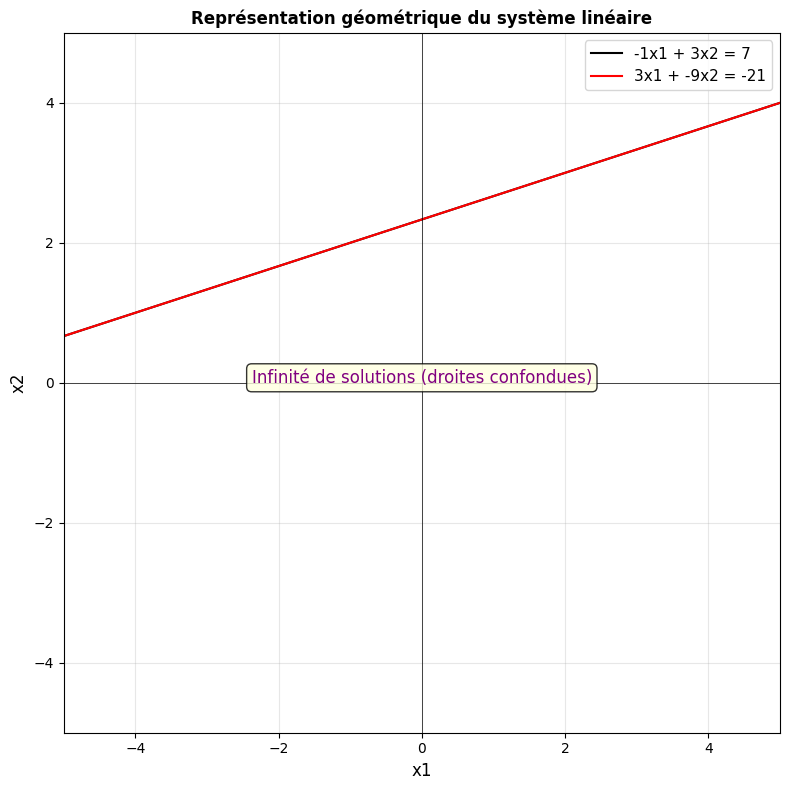

In [20]:
plot_lines(A_3_system)

<a name='3'></a>

## 3 - Elimination gaussienne

L'élimination de Gauss est une méthode systématique pour résoudre un système
d'équations linéaires. L'idée centrale : appliquer des opérations sur les lignes
de la matrice augmentée pour la transformer en une forme où les solutions se lisent
directement.

L'algorithme suit 4 étapes :
1. Construire la matrice augmentée [A|b]
2. Transformer cette matrice en forme échelonnée réduite (pivots = 1, zéros partout ailleurs)
3. Lire les solutions par substitution arrière
4. Encapsuler les étapes 1-3 dans une fonction unique

*Attention : dans ce notebook, les matrices sont carrées et les systèmes non singuliers.*

-**Etape 1 : Matrice augmentée**

On regroupe la matrice des coefficients A et le vecteur des constantes b dans
une seule matrice. Cela permet d'appliquer les opérations de lignes simultanément
sur les coefficients ET les constantes, indispensable pour que les transformations
restent cohérentes avec le système d'origine.


$$
\begin{cases}
2x_1+3x_2+5x_3=12, \\ -3x_1-2x_2+4x_3=-2,\\x_1+x_2-2x_3=8
\end{cases}\
$$

On crée la forme matricielle :

$$ A=
\begin{bmatrix}
2 & 3 & 5 \\
-3 & -2 & 4\\
1 & 1 &-2
\end{bmatrix}
$$


$$ b=
\begin{bmatrix}
12 \\
-2\\
8
\end{bmatrix}
$$

On peut également représenté comme suit


$$
\left[\begin{array}{ccc|c}
2 & 3 & 5 & 12 \\
-3 & -2 & 4 & -2 \\
1 & 1 & -2 & 8
\end{array}\right]
$$

-**Etape 2 : Transformation de la matrice en forme échelonnée réduite**

L'objectif est de transformer la matrice augmentée pour obtenir la matrice identité
à gauche du trait vertical. Cela signifie : des 1 sur la diagonale, des 0 partout ailleurs.

On effectue des opérations sur les lignes pour convertir la matrice augmentée en forme échelonné réduite en :
  - Inversion de ligne
  - Multiplication de lignes
  - Remplacement de ligne


Forme échelonnée réduite : $$
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0\\
0 & 0 &1
\end{bmatrix}
$$

Pour y arriver, on utilise trois opérations élémentaires sur les lignes :
- **Échange de lignes** : si le pivot est nul, on cherche une ligne non nulle en dessous
  et on les échange
- **Multiplication d'une ligne** : on divise une ligne par son pivot pour obtenir un 1
- **Remplacement d'une ligne** : on soustrait un multiple d'une ligne à une autre
  pour obtenir des 0 au-dessus et en dessous du pivot

Ces opérations ne changent pas les solutions du système , elles transforment
uniquement sa représentation matricielle.


-**Étape 3 : Substitution arrière**
La dernière ligne donne directement x3. On remonte ligne par ligne en substituant les valeurs connues pour isoler x2, puis x1.

-**Étape 4 : Compilation**
On encapsule les étapes 1-3 dans `gaussian_elimination(A, B)`, une seule fonction qui prend A et b et retourne le vecteur solution.

<a name='3.1'></a>

### 3.1 - Fonctions auxiliaires
*Fonctions codées dans le cadre d'un TP par DeepLearning AI*

Avant de coder l'algorithme principal, on construit les briques élémentaires.
Chaque fonction remplit une tâche précise et sera appelée par `row_echelon_form`.

####3.1.1 Fonctions d'échange de lignes

Quand le pivot d'une ligne est nul, on ne peut pas diviser par lui.
On cherche alors une ligne en dessous avec une valeur non nulle et on les échange.

Cette fonction prend en entrée un tableau NumPy et deux indices. Elle échange les lignes correspondantes à ces indives. Elle ne modifie pas la matrice d'origine mais en renvoir une nouvelle.

In [21]:
def swap_rows(M, row_index_1, row_index_2):
  M=M.copy()
  M[[row_index_1,row_index_2]]=M[[row_index_2,row_index_1]]
  return M

In [22]:
M=np.array([[2,3,5],[-3,-2,4],[1,1,-2]])
print(f"Matrice initiale : \n{M}")
M_swapped=swap_rows(M,0,2)
print(f"\n Matrice modifié : \n{M_swapped}")

Matrice initiale : 
[[ 2  3  5]
 [-3 -2  4]
 [ 1  1 -2]]

 Matrice modifié : 
[[ 1  1 -2]
 [-3 -2  4]
 [ 2  3  5]]


#### 3.1.2 Recherche de la première valeur non nulle dans une colonne

Avant d'échanger des lignes, il faut savoir où chercher. Cette fonction
parcourt une colonne vers le bas à partir d'une ligne donnée et retourne
l'index de la première valeur non nulle,  utilisée pour trouver un pivot
de remplacement quand le pivot courant est nul.

Paramètres :
- M (np.array) : la matrice d'entrée
- column : l'indice de la colonne à explorer
- starting_row : l'indice de la ligne de départ de la recherche

Retourne :
- int : l'indice de la première valeur non nulle trouvée
- -1 si aucune valeur non nulle n'est trouvée

In [23]:
def get_index_first_non_zero_value_from_column(M, column, starting_row):
  column_array=M[starting_row:,column]
  for i, val in enumerate(column_array):
    if not np.isclose(val,0,atol=1e-5):
      index=i+starting_row
      return index
  return -1

In [24]:
N=np.array([
    [0,5,-3,6,8],
    [0,6,3,8,1],
    [0,0,0,0,0],
    [0,0,0,0,7],
    [0,2,1,0,4]
])
print(get_index_first_non_zero_value_from_column(N,column=1,starting_row=0))

0


#### 3.1.3 Trouver le premier élément non nul d'une ligne

Cette fonction localise le pivot d'une ligne, c'est-à-dire le premier
élément non nul. Le paramètre `augmented=True` permet d'ignorer la dernière
colonne (les constantes b) qui ne sont pas des pivots.

Paramètres :
- M : la matrice d'entrée
- row : l'indice de la ligne à parcourir
- augmented : True si la matrice est augmentée (ignore la dernière colonne)

Retourne :
- int : l'indice de la première valeur non nulle dans la ligne
- -1 si aucune valeur non nulle n'est trouvée

In [25]:
def get_index_first_non_zero_value_from_row(M,row,augmented=False):
  M=M.copy()
  if augmented==True :
    M=M[:,:-1]

  row_array=M[row]
  for i, val in enumerate(row_array):
    if not np.isclose(val,0,atol=1e-5):
      return i
  return -1

In [26]:
print(f"Sortie ligne 2 : {get_index_first_non_zero_value_from_row(N,2)}")
print(f"Sortie ligne 3 : {get_index_first_non_zero_value_from_row(N,3)}")
print(f"Sortie ligne 3 (matrice augmentée) : {get_index_first_non_zero_value_from_row(N,3, augmented=True)}")

Sortie ligne 2 : -1
Sortie ligne 3 : 4
Sortie ligne 3 (matrice augmentée) : -1


#### 3.1.4 Construction de la matrice augmentée
Simple utilitaire qui construit [A|b] via `np.hstack`. Utilisé au début
de `row_echelon_form` pour travailler sur une seule matrice.





In [27]:
def augmented_matrix(A,B):
  augmented_M=np.hstack((A,B))
  return augmented_M

In [28]:
A=np.array([[1,2,3],[3,4,5]])
B=np.array([[1],[5]])
print(augmented_matrix(A,B))

[[1 2 3 1]
 [3 4 5 5]]


<a name='3.2'></a>
###3.2 Forme échelonnée réduite

Cette fonction est le cœur de l'algorithme. Elle transforme la matrice augmentée
[A|b] en forme échelonnée réduite en appliquant les trois opérations élémentaires
sur les lignes. À chaque itération : on identifie le pivot, on échange les lignes
si nécessaire, on normalise la ligne pivot à 1, puis on élimine les valeurs en dessous.

In [29]:
def row_echelon_form(A,B):
  det_A=np.linalg.det(A)
  if np.isclose(det_A,0)==True:
    return 'Singular system'

  A=A.copy()
  B=B.copy()

  A=A.astype('float64')
  B=B.astype('float64')

  num_rows=len(A)

  M=augmented_matrix(A,B)

  for row in range(num_rows):
    pivot_candidate = M[row, row]

    if np.isclose(pivot_candidate, 0) == True:
        first_non_zero = get_index_first_non_zero_value_from_column(M, row, row)
        M = swap_rows(M, row, first_non_zero)
    else:
        pivot = pivot_candidate

    M[row] = 1/pivot * M[row]

    for j in range(row+1, num_rows):
        value_below_pivot = M[j, row]
        M[j] = M[j] - value_below_pivot * M[row]


  return M

In [30]:
A=np.array([[1,2,3],[0,1,0],[0,0,5]])
B=np.array([[1],[2],[4]])
row_echelon_form(A,B)

array([[1. , 2. , 3. , 1. ],
       [0. , 1. , 0. , 2. ],
       [0. , 0. , 1. , 0.8]])

<a name='3.3'></a>
### 3.3 Substitution arrière

Une fois la forme échelonnée obtenue, chaque ligne ne contient plus qu'une
inconnue. On peut lire les solutions directement dans la dernière colonne.

La substitution arrière remonte de la dernière ligne vers la première :
- Dernière ligne → donne x3 directement
- Avant-dernière ligne → on élimine x3 pour lire x2
- Première ligne → on élimine x2 et x3 pour lire x1

C'est l'équivalent matriciel de ce qu'on fait à la main quand on résout
un système par substitution.

Paramètre :
- M : la matrice augmentée sous forme échelonnée réduite avec pivots = 1, de shape (n, n+1)

Retourne :
- le vecteur solution du système linéaire

In [31]:
def back_substitution(M):
  M=M.copy()
  num_rows=M.shape[0]

  for row in reversed(range(num_rows)):
    substitution_row=M[row].copy()
    index=row

    for j in range(row):
      row_to_reduce=M[j].copy()
      value=row_to_reduce[index]
      row_to_reduce=row_to_reduce - value*substitution_row
      M[j,:]=row_to_reduce

  solution = M[:,-1]
  return solution

In [32]:
back_substitution(M)

array([39, 12, -2])

<a name='3.4'></a>
###3.4 Elimination de Gauss


On enchaîne les trois étapes dans une fonction unique :
```
augmented_matrix(A, B)        # construit [A|b]
        ↓
row_echelon_form(A, B)        # transforme [A|b] en forme échelonnée réduite
        ↓
back_substitution(M)          # lit les solutions dans la dernière colonne
        ↓
solution [x1, x2, x3]
```

En pratique, `np.linalg.solve(A, b)` fait exactement la même chose en une
ligne. L'intérêt de coder l'algorithme à la main : comprendre ce qui se
passe sous le capot.

In [33]:
def gaussian_elimination(A,B):
  row_echelon_M=row_echelon_form(A,B)
  solution = back_substitution(row_echelon_M)
  return solution

In [34]:
A=np.array([[3,6,6,8],[5,3,6,0],[0,4,-5,8],[0,0,4,8]])
B=np.array([[1],[-10],[8],[9]])
sols=gaussian_elimination(A,B)
print(sols)

[-1.54140127 -0.52229299 -0.12101911  1.18550955]


<a name='4'></a>
## 4. Multiplication matricielle

Le produit de deux matrices A (m×n) et B (n×p) est une matrice C (m×p) dont chaque entrée est le produit scalaire d'une ligne de A et d'une colonne de B.La multiplication matricielle **n'est pas commutative**


Si $A$ est une matrice $m \times n$ et $B$ une matrice $n \times p$, le produit matriciel $C = AB$ (noté sans signe de multiplication ni point) est défini comme la matrice $m \times p$ telle que :

$c_{ij}=a_{i1}b_{1j}+a_{i2}b_{2j}+\ldots+a_{in}b_{nj}=\sum_{k=1}^{n} a_{ik}b_{kj}, \$

où $a_{ik}$ sont les éléments de la matrice $A$, $b_{kj}$ sont les éléments de la matrice $B$, et $i = 1, \ldots, m$, $k = 1, \ldots, n$, $j = 1, \ldots, p$. En d'autres termes, $c_{ij}$ est le produit scalaire de la $i$-ème ligne de $A$ et de la $j$-ème colonne de $B$.

<a name='4.1'></a>

### 4.1 - Multiplication de matrices avec Python

Il existe plusieurs façons d'effectuer une multiplication de matrices en Python. Les calculs sont plus efficaces sous forme vectorielle.

In [35]:
A=np.array([[4,9,9],[9,1,6],[9,2,3]])
B=np.array([[2,2],[5,7],[4,4]])

print(f"Matrice A (3x3) : \n{A} \n Matrice B (3x2) : \n{B}")

Matrice A (3x3) : 
[[4 9 9]
 [9 1 6]
 [9 2 3]] 
 Matrice B (3x2) : 
[[2 2]
 [5 7]
 [4 4]]


In [36]:
#Multiplication des matrices A et B avec la fonction np.matmul du package NumPy
np.matmul(A,B)

array([[ 89, 107],
       [ 47,  49],
       [ 40,  44]])

In [39]:
#Multipliation avec l'opérateur @
A@B

array([[ 89, 107],
       [ 47,  49],
       [ 40,  44]])

<a name='4.2'></a>

### 4.2 - Convention matricielle et Broadcasting

#### Règle des dimensions

La multiplication matricielle n'est définie que si le nombre de colonnes de A
est égal au nombre de lignes de B. Si ce n'est pas le cas, NumPy lève une erreur.

B est (3×2) et A est (3×3) , on ne peut pas faire B@A car 2 ≠ 3.

In [49]:
try :
  np.matmul(B,A)
except ValueError as err:
  print(f"Erreur: {err}")

Erreur: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)


#### Comportement particulier des vecteurs 1D

Un vecteur NumPy 1D de shape `(n,)` n'est ni une ligne ni une colonne ,
c'est un objet à part. Quand on le multiplie avec `np.matmul`, NumPy le
transpose automatiquement pour que l'opération réussisse.

C'est pratique, mais silencieux , aucune erreur ne signale la transposition.

In [50]:
x = np.array([1, -2, -5])   # shape (3,)
y = np.array([4, 3, -1])    # shape (3,)

print(f"Shape de x        : {x.shape}")
print(f"Shape de x colonne: {x.reshape((3,1)).shape}")

# NumPy transpose x automatiquement → résultat = produit scalaire
print(f"\nnp.matmul(x, y) = {np.matmul(x, y)}")
print(f"Vérification x@y  = {x@y}")

# Avec des vecteurs colonnes explicites → erreur car (3,1) @ (3,1) impossible
try:
    np.matmul(x.reshape((3,1)), y.reshape((3,1)))
except ValueError as err:
    print(f"\nAvec vecteurs colonnes explicites : {err}")

Shape de x        : (3,)
Shape de x colonne: (3, 1)

np.matmul(x, y) = 3
Vérification x@y  = 3

Avec vecteurs colonnes explicites : matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 1)


#### Broadcasting

Le broadcasting est un mécanisme NumPy qui permet d'effectuer des opérations
entre tableaux de shapes différentes, sans créer de copie en mémoire.

Règle simple : NumPy "étire" virtuellement le plus petit tableau pour qu'il
corresponde à la shape du plus grand.

Trois cas courants :
- **Scalaire × matrice** : le scalaire est appliqué à chaque élément
- **Vecteur × matrice** : le vecteur est appliqué à chaque ligne (ou colonne)
- **Matrices compatibles** : shapes alignées depuis la droite avec des 1

Le broadcasting ne transgresse pas les règles mathématiques, il définit
ses propres règles pour les opérations élément par élément.

In [52]:
# Cas 1 : scalaire appliqué à toute la matrice
print("A - 2 (scalaire) :\n", A - 2)

# Cas 2 : vecteur soustrait à chaque ligne de la matrice
moyenne = np.array([1, 2, 3])  # shape (3,)
print(f"\nMoyenne : {moyenne}")
print(f"A - moyenne (broadcasting vecteur) :\n", A - moyenne)

# Cas 3 : piège , * vs @
# On utilise deux matrices de même shape pour illustrer la différence
C = np.array([[1, 2], [3, 4], [5, 6]])  # shape (3×2)
D = np.array([[2, 0], [1, 3], [0, 2]])  # shape (3×2)

print("C * D (produit élément par élément) :\n", C * D)
print("\nC.T @ D (produit matriciel (2×3)@(3×2) → (2×2)) :\n", C.T @ D)
print("\nLes deux opérations réussissent sans erreur mais donnent des résultats complètement différents.")

A - 2 (scalaire) :
 [[ 2  7  7]
 [ 7 -1  4]
 [ 7  0  1]]

Moyenne : [1 2 3]
A - moyenne (broadcasting vecteur) :
 [[ 3  7  6]
 [ 8 -1  3]
 [ 8  0  0]]
C * D (produit élément par élément) :
 [[ 2  0]
 [ 3 12]
 [ 0 12]]

C.T @ D (produit matriciel (2×3)@(3×2) → (2×2)) :
 [[ 5 19]
 [ 8 24]]

Les deux opérations réussissent sans erreur mais donnent des résultats complètement différents.




Le piège classique : utiliser `*` au lieu de `@`.
Les deux réussissent sans erreur si les shapes sont compatibles,
mais les résultats sont complètement différents.

<a name='5'></a>

## 5. Transformations linéaires



<a name='5.1'></a>
### 5.1 Transformations

Une transformation prend un vecteur en entrée et retourne un autre vecteur.
On note T(v) = w , v est transformé en w.

L'exemple ci-dessous transforme un vecteur de R² en vecteur de R³ :

$$T\begin{pmatrix}\begin{bmatrix}v_1 \\ v_2\end{bmatrix}\end{pmatrix}=
\begin{bmatrix}3v_1 \\ 0 \\ -2v_2\end{bmatrix}$$

Concrètement : la première composante est multipliée par 3,
la deuxième est annulée, la troisième vaut -2 fois v2.

Ce n'est pas encore une transformation linéaire au sens strict ,
c'est juste une fonction qui transforme des vecteurs. La section
suivante précise ce qui rend une transformation "linéaire".

In [54]:
def T(v):
    w = np.zeros((3,1))
    w[0,0] = 3*v[0,0]
    w[2,0] = -2*v[1,0]

    return w

v = np.array([[3], [5]])
w = T(v)

print("Vecteur original:\n", v, "\n\n Résultat de la transformation:\n", w)

Original vector:
 [[3]
 [5]] 

 Result of the transformation:
 [[  9.]
 [  0.]
 [-10.]]


<a name='5.2'></a>

### 5.2 - Transformation linéaire

Une transformation est **linéaire** si elle respecte deux propriétés :

1. T(k×v) = k×T(v) , multiplier l'entrée par k revient à multiplier la sortie par k
2. T(u+v) = T(u)+T(v) , transformer une somme = somme des transformations

**Intuition** : une transformation linéaire ne courbe pas l'espace.
Elle peut l'étirer, le comprimer, le faire pivoter, le projeter ,
mais les lignes droites restent droites et l'origine reste à l'origine.

**Mécanique** , vérification sur la propriété 1 :

$$T(kv) = \begin{bmatrix}3kv_1 \\ 0 \\ -2kv_2\end{bmatrix} =
k\begin{bmatrix}3v_1 \\ 0 \\ -2v_2\end{bmatrix} = kT(v) \checkmark$$

Le code ci-dessous vérifie les deux propriétés sur des valeurs concrètes.




In [58]:
u = np.array([[1], [-2]])
v = np.array([[2], [4]])

k = 7

print("T(k*v):\n", T(k*v), "\n k*T(v):\n", k*T(v), "\n\n")
print("T(u+v):\n", T(u+v), "\n T(u)+T(v):\n", T(u)+T(v))

T(k*v):
 [[ 42.]
 [  0.]
 [-56.]] 
 k*T(v):
 [[ 42.]
 [  0.]
 [-56.]] 


T(u+v):
 [[ 9.]
 [ 0.]
 [-4.]] 
 T(u)+T(v):
 [[ 9.]
 [ 0.]
 [-4.]]


<a name='5.3'></a>

### 5.3 - Transformations définies comme une multiplication matricielle

Résultat fondamental : toute transformation linéaire s'écrit A @ v.

**Intuition** : pour construire la matrice A d'une transformation,
il suffit de regarder ce qu'elle fait aux vecteurs de base e1 et e2 :
- 1ère colonne de A = image de e1
- 2ème colonne de A = image de e2

**Mécanique** , on développe A @ v et on identifie les coefficients :

$$A\begin{bmatrix}v_1 \\ v_2\end{bmatrix} =
\begin{bmatrix}a_{1,1}v_1+a_{1,2}v_2 \\ a_{2,1}v_1+a_{2,2}v_2 \\
a_{3,1}v_1+a_{3,2}v_2\end{bmatrix} =
\begin{bmatrix}3v_1 \\ 0 \\ -2v_2\end{bmatrix}$$

On lit directement : a₁₁=3, a₁₂=0, a₂₁=0, a₂₂=0, a₃₁=0, a₃₂=-2.

$$A = \begin{bmatrix}3 & 0 \\ 0 & 0 \\ 0 & -2\end{bmatrix}$$

**Lien ML** : chaque couche d'un réseau de neurones est une matrice
de transformation , elle déforme l'espace des données pour rendre
les classes séparables.

In [57]:
#Détermine les valeurs des éléments aij dela matrice A pour que l'égalité soit correcte
def L(v):
    A = np.array([[3,0], [0,0], [0,-2]])
    print("Matrice de transformation:\n", A, "\n")
    w = A @ v

    return w

v = np.array([[3], [5]])
w = L(v)

print("Vecteur original:\n", v, "\n\n Résultat de la transformation:\n", w)

Matrice de transformation:
 [[ 3  0]
 [ 0  0]
 [ 0 -2]] 

Vecteur original:
 [[3]
 [5]] 

 Résultat de la transformation:
 [[  9]
 [  0]
 [-10]]


<a name='5.4'></a>

### 5.4 - Transformations standards dans le plan

Pour visualiser ce que fait une transformation, le meilleur choix
est de l'appliquer aux vecteurs de base e1=[1,0] et e2=[0,1].

**Pourquoi e1 et e2 ?**
Parce que toute matrice A vérifie :

$$A = \begin{bmatrix}L(e_1) & L(e_2)\end{bmatrix}$$

Les colonnes de A sont exactement les images de e1 et e2.
Pour lire une matrice de transformation, il suffit donc de regarder
ses colonnes — elles te disent où vont les axes après transformation.


#### 5.4.1 - Dilatation horizontale
**Intuition** : étirer l'espace dans une direction, comme si tu tirais
sur un élastique horizontalement.

**Mécanique** : la matrice `[[2,0],[0,1]]` dit :
- e1=[1,0] → [2,0] : l'axe x est doublé
- e2=[0,1] → [0,1] : l'axe y est inchangé

Tout point voit sa coordonnée x multipliée par 2, y reste identique.
Un carré devient un rectangle.

**En ML** : la normalisation des features est une dilatation.
Diviser une feature par son écart-type comprime son axe pour
le ramener à la même échelle que les autres. Sans ça,
les algorithmes comme KNN ou le gradient descent sont biaisés
vers les features aux grandes valeurs.

In [60]:
def T_hscaling(v):
    A = np.array([[2,0], [0,1]])
    w = A @ v

    return w


def transform_vectors(T, v1, v2):
    V = np.hstack((v1, v2))
    W = T(V)

    return W

e1 = np.array([[1], [0]])
e2 = np.array([[0], [1]])

transformation_result_hscaling = transform_vectors(T_hscaling, e1, e2)

print("Vecteur original:\n e1= \n", e1, "\n e2=\n", e2,
      "\n\n Résultat de la transformation :\n", transformation_result_hscaling)

Vecteur original:
 e1= 
 [[1]
 [0]] 
 e2=
 [[0]
 [1]] 

 Résultat de la transformation :
 [[2 0]
 [0 1]]


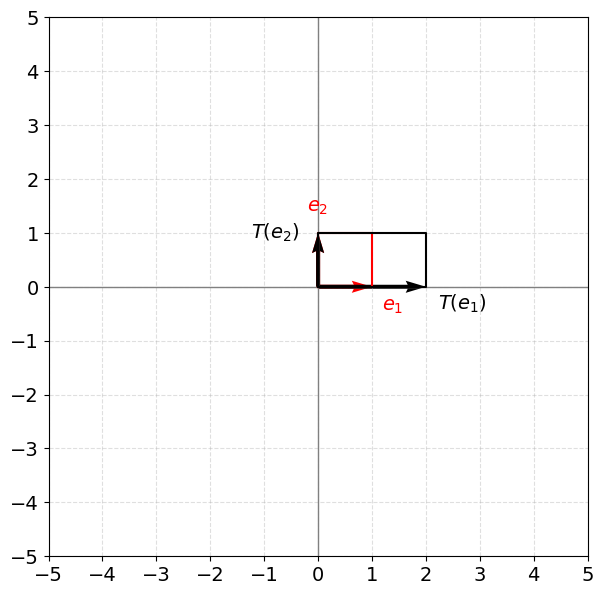

In [97]:
def plot_transformation(T, e1, e2):
    color_original = "red"
    color_transformed = "black"

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(np.arange(-5, 6))
    ax.set_yticks(np.arange(-5, 6))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)

    # Original basis vectors
    ax.quiver([0, 0], [0, 0], [e1[0], e2[0]], [e1[1], e2[1]],
              color=color_original, angles='xy', scale_units='xy', scale=1)
    ax.plot([0, e2[0], e1[0]+e2[0], e1[0], 0],
            [0, e2[1], e1[1]+e2[1], e1[1], 0],
            color=color_original)
    # e1 and e2 labels (with custom non-overlapping offset)
    ax.text(e1[0]+0.18, e1[1]-0.18, '$e_1$', fontsize=14, color=color_original, ha='left', va='top')
    ax.text(e2[0], e2[1]+0.3, '$e_2$', fontsize=14, color=color_original, ha='center', va='bottom')

    # Transformed basis
    e1_t = T(e1)
    e2_t = T(e2)
    ax.quiver([0, 0], [0, 0], [e1_t[0], e2_t[0]], [e1_t[1], e2_t[1]],
              color=color_transformed, angles='xy', scale_units='xy', scale=1)
    ax.plot([0, e2_t[0], e1_t[0]+e2_t[0], e1_t[0], 0],
            [0, e2_t[1], e1_t[1]+e2_t[1], e1_t[1], 0],
            color=color_transformed)
    # Transformed labels, **different offset to avoid overlap!**
    ax.text(e1_t[0]+0.22, e1_t[1]-0.10, '$T(e_1)$', fontsize=14, color=color_transformed, ha='left', va='top')
    ax.text(e2_t[0]-0.35, e2_t[1], '$T(e_2)$', fontsize=14, color=color_transformed, ha='right', va='center')

    ax.set_aspect("equal")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()



e1 = np.array([1,0])
e2 = np.array([0,1])

plot_transformation(T_hscaling, e1, e2)

### 5.4.2 - Réflexion par rapport à l'axe y

**Intuition** : retourner l'espace comme dans un miroir vertical.

**Mécanique** : la matrice `[[-1,0],[0,1]]` dit :
- e1=[1,0] → [-1,0] : l'axe x est retourné
- e2=[0,1] → [0,1] : l'axe y est inchangé

Tout point voit sa coordonnée x changer de signe.

**Propriété remarquable** : appliquer la réflexion deux fois
redonne le vecteur d'origine — A² = I (matrice identité).

**En ML** : technique de data augmentation — retourner des images
horizontalement pour enrichir un dataset d'entraînement sans
collecter de nouvelles données.

In [83]:
def T_reflection_yaxis(v):

    A = np.array([[-1,0], [0,1]])

    return A @ v

e1 = np.array([1, 0])
e2 = np.array([0, 1])

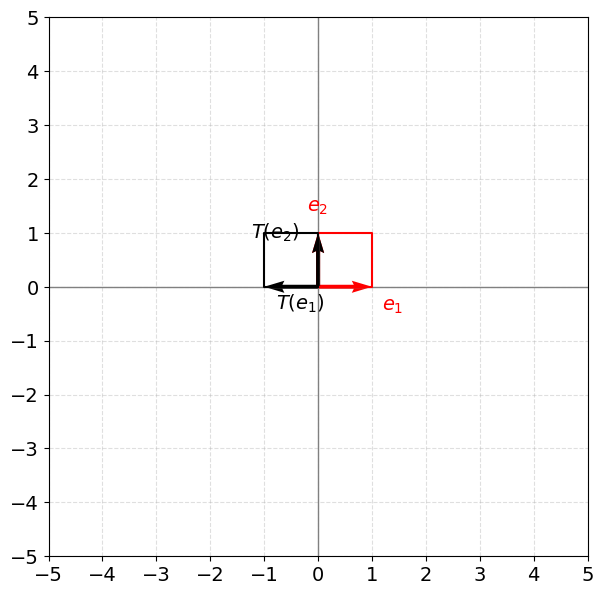

In [84]:
plot_transformation(T_reflection_yaxis, e1, e2)

Les transformations vues sur e1 et e2 s'appliquent exactement
de la même façon sur une image — pixel par pixel, via cv2.warpPerspective.

<a name='5.5'></a>
## 5.5 - Application : infographie et traitement d'image

Une image c'est une matrice de pixels. Chaque pixel a une position —
un vecteur de coordonnées [x, y]. Appliquer une transformation linéaire
à une image revient à appliquer la matrice de transformation à chaque
vecteur position.

`cv2.warpPerspective` fait exactement ça — c'est `A @ v` appliqué
à chaque pixel. OpenCV exige une matrice 3×3 même pour des transformations
2D : la troisième ligne `[0, 0, 1]` est une convention technique.

In [90]:
# Chargement de l'image
img = cv2.imread('preparation_formation/notebooks/images/image_chat.jpg', 0)
rows, cols = img.shape

### 5.5.1 - Dilatation

Étire l'image horizontalement d'un facteur 1.5.  
e1=[1,0] → [1.5, 0] : l'axe x est étiré  
e2=[0,1] → [0, 1] : l'axe y est inchangé

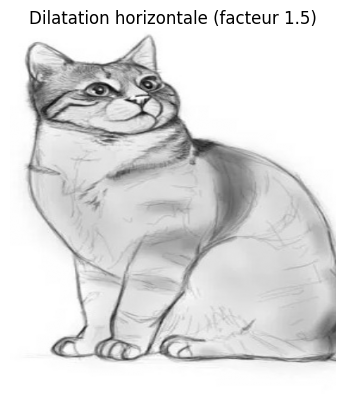

In [91]:
M_dilatation = np.float32([[1.5, 0, 0],
                            [0,   1, 0],
                            [0,   0, 1]])

img_dilatation = cv2.warpPerspective(img, M_dilatation, (cols, rows))
plt.imshow(img_dilatation, cmap='gray')
plt.title("Dilatation horizontale (facteur 1.5)")
plt.axis('off')
plt.show()

### 5.5.2 - Cisaillement

Penche l'image horizontalement — les pixels du haut se décalent vers la droite.  
e1=[1,0] → [1, 0] : inchangé  
e2=[0,1] → [0.5, 1] : l'axe y est penché

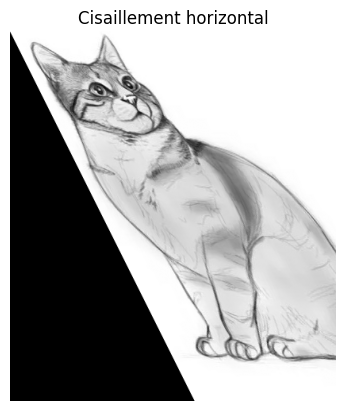

In [92]:
M_cisaillement = np.float32([[1, 0.5, 0],
                              [0, 1,   0],
                              [0, 0,   1]])

img_cisaillement = cv2.warpPerspective(img, M_cisaillement, (cols, rows))
plt.imshow(img_cisaillement, cmap='gray')
plt.title("Cisaillement horizontal")
plt.axis('off')
plt.show()

### 5.5.3 - Rotation 90° horaire

Fait pivoter l'image de 90° dans le sens des aiguilles d'une montre.  
OpenCV fournit une fonction dédiée pour les rotations standards.

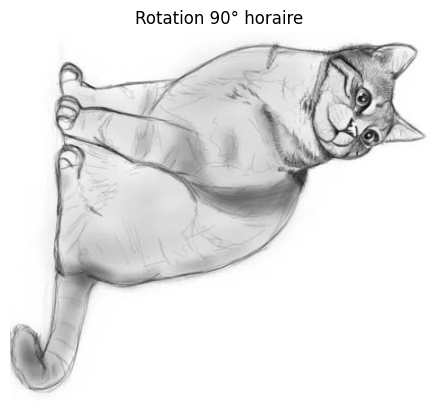

In [93]:
img_rotation = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
plt.imshow(img_rotation, cmap='gray')
plt.title("Rotation 90° horaire")
plt.axis('off')
plt.show()

### 5.5.4 - Réflexion

Retourne l'image horizontalement — effet miroir par rapport à l'axe y.  
e1=[1,0] → [-1, 0] : l'axe x est retourné  
e2=[0,1] → [0, 1] : l'axe y est inchangé

La translation `cols-1` ramène l'image dans le cadre visible —
sans elle, l'image retournée sortirait du cadre à gauche.

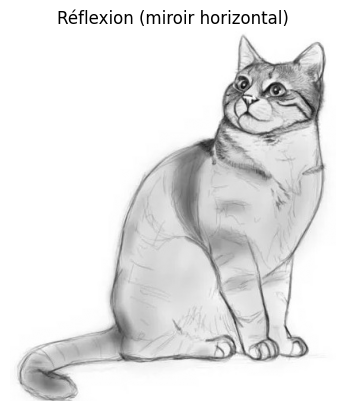

In [94]:
M_reflexion = np.float32([[-1, 0, cols-1],
                           [0,  1, 0],
                           [0,  0, 1]])

img_reflexion = cv2.warpPerspective(img, M_reflexion, (cols, rows))
plt.imshow(img_reflexion, cmap='gray')
plt.title("Réflexion (miroir horizontal)")
plt.axis('off')
plt.show()

### 5.5.5 - L'ordre des transformations compte

Appliquer rotation puis cisaillement ne donne pas le même résultat
que cisaillement puis rotation. C'est la non-commutativité de la
multiplication matricielle vue sur une image concrète : BA ≠ AB.

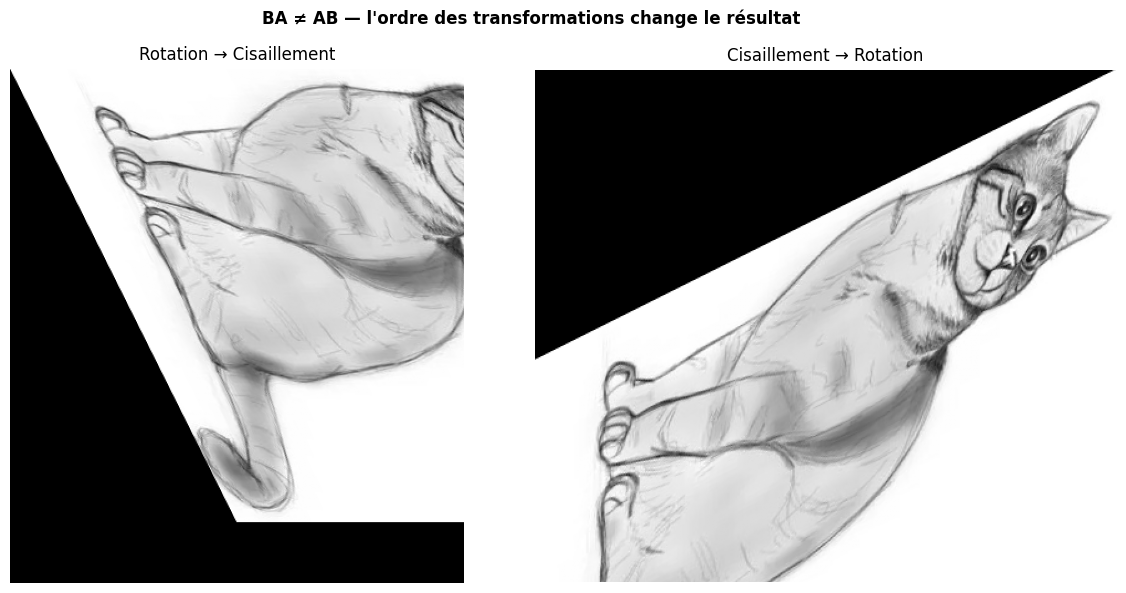

In [95]:
# Rotation puis cisaillement
img_rot_shear = cv2.warpPerspective(
    cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),
    M_cisaillement, (cols, rows)
)

# Cisaillement puis rotation
img_shear_rot = cv2.rotate(
    cv2.warpPerspective(img, M_cisaillement, (cols, rows)),
    cv2.ROTATE_90_CLOCKWISE
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rot_shear, cmap='gray')
axes[0].set_title("Rotation → Cisaillement")
axes[0].axis('off')

axes[1].imshow(img_shear_rot, cmap='gray')
axes[1].set_title("Cisaillement → Rotation")
axes[1].axis('off')

plt.suptitle("BA ≠ AB — l'ordre des transformations change le résultat",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Vérification matricielle**

In [96]:
M_rotation_90_clockwise = np.array([[0, 1], [-1, 0]])
M_shear_x = np.array([[1, 0.5], [0, 1]])

print("Rotation @ Cisaillement :\n", M_rotation_90_clockwise @ M_shear_x)
print("\nCisaillement @ Rotation :\n", M_shear_x @ M_rotation_90_clockwise)
print("\nRésultats différents → BA ≠ AB confirmé")

Rotation @ Cisaillement :
 [[ 0.   1. ]
 [-1.  -0.5]]

Cisaillement @ Rotation :
 [[-0.5  1. ]
 [-1.   0. ]]

Résultats différents → BA ≠ AB confirmé
